In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import skill_metrics as sm

import darts
from darts import TimeSeries
from darts.utils.statistics import plot_ccf, plot_acf

from darts.utils.missing_values import extract_subseries
from darts.utils.missing_values import fill_missing_values

from darts.dataprocessing.transformers import Scaler
from darts.models import LinearRegressionModel

In [2]:
data_file = Path("../terrestrial_daily-targets.csv")
cov_file = Path("../weather_data/NOAA_stage3_daily_mean_sd_all_sites.csv")
reference_date = pd.Timestamp('2000-01-01')

In [3]:
input_chunk_length = 30
output_chunk_length = 30

data = pd.read_csv(data_file, parse_dates=['datetime'])
cov = pd.read_csv(cov_file, parse_dates=['date'])
data = data.loc[data['datetime'] >= "2020-09-24 00:00:00+00:00"] # datos meteorológicos disponibles

sites = ['BONA', 'JERC', 'OSBS', 'RMNP', 'SJER', 'SOAP', 'TALL', 'TEAK', 'WREF', 'YELL', 'ABBY']
variables = ["le","nee"]
freq = "D"
MIN_GAP_SIZE = 7

In [4]:
abby = data.loc[data["site_id"] == "ABBY"].pivot(index="datetime", columns="variable", values="observation")

fut_tgt = abby.loc[("2025-07-14" <= abby.index) * (abby.index <= "2025-08-12")]

future_target = TimeSeries.from_dataframe(
    fut_tgt,
    time_col=None,
    value_cols=variables,
    fill_missing_dates=True,
    freq=freq,
)

The provided DatetimeIndex was associated with a timezone (tz), which is currently not supported. To avoid unexpected behaviour, the tz information was removed. Consider calling `ts.time_index.tz_localize(UTC)` when exporting the results.To plot the series with the right time steps, consider setting the matplotlib.pyplot `rcParams['timezone']` parameter to automatically convert the time axis back to the original timezone.


In [5]:
tgt_segments = []
fcov_segments = []

for site in sites:
    site_data = data.loc[data["site_id"] == site].pivot(index="datetime", columns="variable", values="observation")
    site_data = site_data.loc[site_data.index <= "2025-07-13"] if site == "ABBY" else site_data

    cov_mean = cov.loc[cov["site_id"] == site].pivot(index="date", columns="variable", values="mean_daily_prediction")
    cov_sd = cov.loc[cov["site_id"] == site].pivot(index="date", columns="variable", values="sd_daily_prediction")
    fcov = cov_mean.add_suffix("_mean").join(cov_sd.add_suffix("_sd")).sort_index(axis=1)
    fcov["sin_doy"] = np.sin(np.pi*2*fcov.index.dayofyear/365.25)
    fcov["cos_doy"] = np.cos(np.pi*2*fcov.index.dayofyear/365.25)
    fcov["day"] = (fcov.index.tz_localize(None) - reference_date).days
    
    target = TimeSeries.from_dataframe(
        site_data,
        time_col=None,
        value_cols=variables,
        fill_missing_dates=True,
        freq=freq,
    )
    
    future_cov_full = TimeSeries.from_dataframe(
        fcov,
        fill_missing_dates=True,
        freq=freq,
    )
    
    # Segmentos
    target_segments = extract_subseries(
        target,
        min_gap_size=MIN_GAP_SIZE,
        mode="any", 
    )
    
    target_segments = [
        fill_missing_values(seg) for seg in target_segments if len(seg) >= input_chunk_length + output_chunk_length
    ]
    df.iloc[::-1]
    future_cov_segments = []
    
    for seg in target_segments:
        cov_seg = future_cov_full.slice_intersect(seg)
        future_cov_segments.append(cov_seg)

    print(f"For {site} the segments are:")
    for i, (y, x) in enumerate(zip(target_segments, future_cov_segments)):
        print("    ",i, y.start_time(), y.end_time(), len(y), len(x))

    tgt_segments += target_segments
    fcov_segments += future_cov_segments

The provided DatetimeIndex was associated with a timezone (tz), which is currently not supported. To avoid unexpected behaviour, the tz information was removed. Consider calling `ts.time_index.tz_localize(UTC)` when exporting the results.To plot the series with the right time steps, consider setting the matplotlib.pyplot `rcParams['timezone']` parameter to automatically convert the time axis back to the original timezone.
The provided DatetimeIndex was associated with a timezone (tz), which is currently not supported. To avoid unexpected behaviour, the tz information was removed. Consider calling `ts.time_index.tz_localize(UTC)` when exporting the results.To plot the series with the right time steps, consider setting the matplotlib.pyplot `rcParams['timezone']` parameter to automatically convert the time axis back to the original timezone.
The provided DatetimeIndex was associated with a timezone (tz), which is currently not supported. To avoid unexpected behaviour, the tz information 

For BONA the segments are:
     0 2020-11-22 00:00:00 2021-06-18 00:00:00 209 209
     1 2021-08-04 00:00:00 2022-03-04 00:00:00 213 213
     2 2022-03-20 00:00:00 2022-06-14 00:00:00 87 87
     3 2022-08-05 00:00:00 2022-12-13 00:00:00 131 131
     4 2023-01-30 00:00:00 2023-08-06 00:00:00 189 189
     5 2024-02-10 00:00:00 2024-06-30 00:00:00 142 142
     6 2024-07-09 00:00:00 2024-10-21 00:00:00 105 105
     7 2025-02-13 00:00:00 2025-06-22 00:00:00 130 130
For JERC the segments are:
     0 2020-09-24 00:00:00 2021-02-03 00:00:00 133 133
     1 2021-04-14 00:00:00 2021-07-19 00:00:00 97 97
     2 2021-11-10 00:00:00 2022-04-19 00:00:00 161 161
     3 2022-04-30 00:00:00 2023-02-27 00:00:00 304 304
     4 2023-03-08 00:00:00 2023-06-19 00:00:00 104 104
     5 2023-12-08 00:00:00 2024-02-05 00:00:00 60 60
     6 2024-04-24 00:00:00 2024-12-16 00:00:00 237 237
     7 2025-04-30 00:00:00 2025-08-11 00:00:00 104 104
     8 2025-08-28 00:00:00 2025-11-25 00:00:00 90 90
     9 2026-01-08 0

The provided DatetimeIndex was associated with a timezone (tz), which is currently not supported. To avoid unexpected behaviour, the tz information was removed. Consider calling `ts.time_index.tz_localize(UTC)` when exporting the results.To plot the series with the right time steps, consider setting the matplotlib.pyplot `rcParams['timezone']` parameter to automatically convert the time axis back to the original timezone.
The provided DatetimeIndex was associated with a timezone (tz), which is currently not supported. To avoid unexpected behaviour, the tz information was removed. Consider calling `ts.time_index.tz_localize(UTC)` when exporting the results.To plot the series with the right time steps, consider setting the matplotlib.pyplot `rcParams['timezone']` parameter to automatically convert the time axis back to the original timezone.


For OSBS the segments are:
     0 2020-12-23 00:00:00 2021-04-28 00:00:00 127 127
     1 2021-06-23 00:00:00 2021-10-31 00:00:00 131 131
     2 2021-11-18 00:00:00 2022-02-08 00:00:00 83 83
     3 2022-02-26 00:00:00 2022-04-26 00:00:00 60 60
     4 2022-11-25 00:00:00 2023-02-03 00:00:00 71 71
     5 2023-04-08 00:00:00 2023-06-10 00:00:00 64 64
     6 2023-07-28 00:00:00 2023-10-23 00:00:00 88 88
     7 2024-01-19 00:00:00 2024-03-20 00:00:00 62 62
     8 2024-06-14 00:00:00 2024-10-30 00:00:00 139 139
     9 2024-12-03 00:00:00 2025-06-28 00:00:00 208 208
     10 2025-09-01 00:00:00 2026-02-15 00:00:00 168 168
     11 2026-03-06 00:00:00 2026-05-09 00:00:00 65 65
For RMNP the segments are:
     0 2020-12-11 00:00:00 2021-02-28 00:00:00 80 80
     1 2021-03-10 00:00:00 2021-07-05 00:00:00 118 118
     2 2021-09-15 00:00:00 2022-05-12 00:00:00 240 240
     3 2022-05-26 00:00:00 2022-09-09 00:00:00 107 107
     4 2022-09-21 00:00:00 2023-08-31 00:00:00 345 345
     5 2023-09-08 00:00:0

The provided DatetimeIndex was associated with a timezone (tz), which is currently not supported. To avoid unexpected behaviour, the tz information was removed. Consider calling `ts.time_index.tz_localize(UTC)` when exporting the results.To plot the series with the right time steps, consider setting the matplotlib.pyplot `rcParams['timezone']` parameter to automatically convert the time axis back to the original timezone.
The provided DatetimeIndex was associated with a timezone (tz), which is currently not supported. To avoid unexpected behaviour, the tz information was removed. Consider calling `ts.time_index.tz_localize(UTC)` when exporting the results.To plot the series with the right time steps, consider setting the matplotlib.pyplot `rcParams['timezone']` parameter to automatically convert the time axis back to the original timezone.


For SJER the segments are:
     0 2020-11-26 00:00:00 2021-02-14 00:00:00 81 81
     1 2021-03-19 00:00:00 2021-09-30 00:00:00 196 196
     2 2021-10-08 00:00:00 2021-12-22 00:00:00 76 76
     3 2022-01-19 00:00:00 2024-03-13 00:00:00 785 785
     4 2024-03-21 00:00:00 2025-01-06 00:00:00 292 292
     5 2025-01-16 00:00:00 2025-10-24 00:00:00 282 282
     6 2025-12-23 00:00:00 2026-05-10 00:00:00 139 139
For SOAP the segments are:
     0 2020-12-24 00:00:00 2021-06-29 00:00:00 188 188
     1 2021-07-26 00:00:00 2021-09-23 00:00:00 60 60
     2 2022-01-05 00:00:00 2022-11-06 00:00:00 306 306
     3 2023-05-10 00:00:00 2024-07-05 00:00:00 423 423
     4 2024-07-17 00:00:00 2025-02-28 00:00:00 227 227
     5 2025-04-30 00:00:00 2025-08-22 00:00:00 115 115


The provided DatetimeIndex was associated with a timezone (tz), which is currently not supported. To avoid unexpected behaviour, the tz information was removed. Consider calling `ts.time_index.tz_localize(UTC)` when exporting the results.To plot the series with the right time steps, consider setting the matplotlib.pyplot `rcParams['timezone']` parameter to automatically convert the time axis back to the original timezone.


For TALL the segments are:
     0 2021-04-07 00:00:00 2021-07-11 00:00:00 96 96
     1 2021-09-03 00:00:00 2021-11-29 00:00:00 88 88
     2 2022-01-19 00:00:00 2022-04-25 00:00:00 97 97
     3 2022-05-17 00:00:00 2022-08-14 00:00:00 90 90
     4 2022-09-09 00:00:00 2023-02-20 00:00:00 165 165
     5 2024-11-23 00:00:00 2025-04-12 00:00:00 141 141
For TEAK the segments are:
     0 2021-04-23 00:00:00 2021-09-21 00:00:00 152 152
     1 2022-03-10 00:00:00 2022-07-25 00:00:00 138 138
     2 2022-08-06 00:00:00 2022-12-10 00:00:00 127 127
     3 2023-04-18 00:00:00 2024-01-31 00:00:00 289 289
     4 2024-02-08 00:00:00 2024-06-27 00:00:00 141 141
     5 2024-07-18 00:00:00 2024-10-01 00:00:00 76 76
     6 2024-10-10 00:00:00 2025-02-12 00:00:00 126 126
     7 2025-02-28 00:00:00 2025-08-28 00:00:00 182 182
     8 2025-11-25 00:00:00 2026-05-10 00:00:00 167 167


The provided DatetimeIndex was associated with a timezone (tz), which is currently not supported. To avoid unexpected behaviour, the tz information was removed. Consider calling `ts.time_index.tz_localize(UTC)` when exporting the results.To plot the series with the right time steps, consider setting the matplotlib.pyplot `rcParams['timezone']` parameter to automatically convert the time axis back to the original timezone.
The provided DatetimeIndex was associated with a timezone (tz), which is currently not supported. To avoid unexpected behaviour, the tz information was removed. Consider calling `ts.time_index.tz_localize(UTC)` when exporting the results.To plot the series with the right time steps, consider setting the matplotlib.pyplot `rcParams['timezone']` parameter to automatically convert the time axis back to the original timezone.
The provided DatetimeIndex was associated with a timezone (tz), which is currently not supported. To avoid unexpected behaviour, the tz information 

For WREF the segments are:
     0 2021-02-28 00:00:00 2021-09-21 00:00:00 206 206
     1 2021-12-31 00:00:00 2022-10-21 00:00:00 295 295
     2 2023-06-01 00:00:00 2023-08-15 00:00:00 76 76
     3 2024-03-08 00:00:00 2024-10-25 00:00:00 232 232
     4 2025-01-08 00:00:00 2025-05-17 00:00:00 130 130
     5 2025-05-26 00:00:00 2025-12-04 00:00:00 193 193
     6 2025-12-13 00:00:00 2026-05-10 00:00:00 149 149
For YELL the segments are:
     0 2020-12-23 00:00:00 2021-08-30 00:00:00 251 251
     1 2021-09-27 00:00:00 2021-11-26 00:00:00 61 61
     2 2022-02-27 00:00:00 2022-08-09 00:00:00 164 164
     3 2022-08-30 00:00:00 2022-12-13 00:00:00 106 106
     4 2023-03-14 00:00:00 2023-05-15 00:00:00 63 63
     5 2024-05-21 00:00:00 2024-09-04 00:00:00 107 107
     6 2024-10-19 00:00:00 2025-11-08 00:00:00 386 386
     7 2026-02-12 00:00:00 2026-05-08 00:00:00 86 86
For ABBY the segments are:
     0 2020-10-02 00:00:00 2020-12-10 00:00:00 70 70
     1 2020-12-18 00:00:00 2021-12-03 00:00:00 35

In [6]:
target_scaler = Scaler()
future_cov_scaler = Scaler()

target_segments_scaled = target_scaler.fit_transform(target_segments)
future_cov_segments_scaled = future_cov_scaler.fit_transform(future_cov_segments)

recent_target = target_segments_scaled[-1]
future_cov_pred = future_cov_scaler.transform(future_cov_full)

Only 1 TimeSeries (lists) were provided which is lower than the number of series (n=6) used to fit Scaler. This can result in a mismatch between the series and the underlying transformers.


## Temporal Fusion Transformer

In [7]:
from darts.models import TFTModel

In [8]:
tft_model = TFTModel(
    input_chunk_length=input_chunk_length,
    output_chunk_length=output_chunk_length,

    hidden_size=16,
    lstm_layers=1,
    num_attention_heads=1,
    dropout=0.2,
    
    batch_size=32,
    n_epochs=500,
    random_state=42,
)

tft_model.fit(
    series=target_segments_scaled,
    future_covariates=future_cov_segments_scaled,
    verbose=True,
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 15.1 K | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 13.7 K | train
6  | static_context_grn                | _GatedResidualNetwork            | 1.1 K  | train
7  | static_context_hidden_encoder_grn | _GatedResidualNetwork 

Training: |                                                             | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=500` reached.


TFTModel(output_chunk_shift=0, hidden_size=16, lstm_layers=1, num_attention_heads=1, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.2, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=False, skip_interpolation=False, loss_fn=None, likelihood=None, norm_type=LayerNorm, use_static_covariates=True, input_chunk_length=30, output_chunk_length=30, batch_size=32, n_epochs=500, random_state=42)

In [9]:
tft_model.save("robust_tft_model.tft")

In [12]:
import gc

# Force a full garbage collection right now
gc.collect() 

1670

In [13]:
big_tft_model = TFTModel(
    input_chunk_length=input_chunk_length,
    output_chunk_length=output_chunk_length,

    hidden_size=32,
    lstm_layers=1,
    num_attention_heads=1,
    dropout=0.2,
    
    batch_size=32,
    n_epochs=1000,
    random_state=42,
)

big_tft_model.fit(
    series=target_segments_scaled,
    future_covariates=future_cov_segments_scaled,
    verbose=True,
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 0      | train
4  | encoder_vsn                       | _VariableSelectionNetwork        | 24.5 K | train
5  | decoder_vsn                       | _VariableSelectionNetwork        | 21.8 K | train
6  | static_context_grn                | _GatedResidualNetwork            | 4.3 K  | train
7  | static_context_hidden_encoder_grn | _GatedResidualNetwork 

Training: |                                                             | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=1000` reached.


TFTModel(output_chunk_shift=0, hidden_size=32, lstm_layers=1, num_attention_heads=1, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.2, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=False, skip_interpolation=False, loss_fn=None, likelihood=None, norm_type=LayerNorm, use_static_covariates=True, input_chunk_length=30, output_chunk_length=30, batch_size=32, n_epochs=1000, random_state=42)

In [14]:
big_tft_model.save("big_robust_tft_model.tft")

In [65]:
tft_loaded = TFTModel.load("big_robust_tft_model.tft")

pred_tft_scaled = tft_loaded.predict(
    n=30,
    series=recent_target,
    future_covariates=future_cov_pred,
    num_samples=500,
)

Dataset output has a different data type than the dataset the model was trained on; current data type: float64, expected data type: float64. This might cause downstream issues when running the model. If so, make sure all your input data have the expected data type (TimeSeries, static covariates, ...).
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/andres/Courses/fisica_computacional_avanzada/Environments/FAE/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/andres/Courses/fisica_computacional_avanzada/Environments/FAE/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicting: |                                                                 | 0/? [00:00<?, ?it/s]

Only 1 TimeSeries (lists) were provided which is lower than the number of series (n=6) used to fit Scaler. This can result in a mismatch between the series and the underlying transformers.


<Axes: xlabel='datetime'>

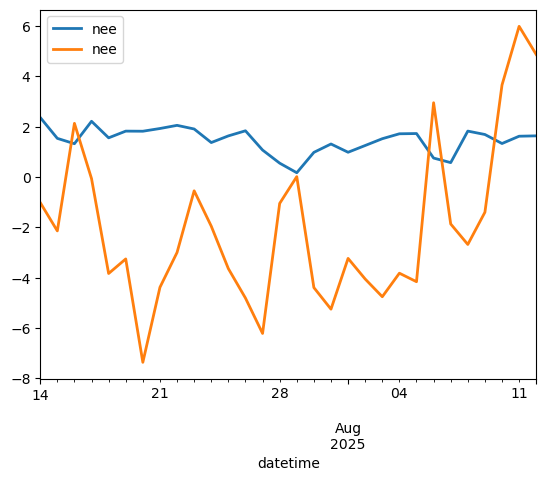

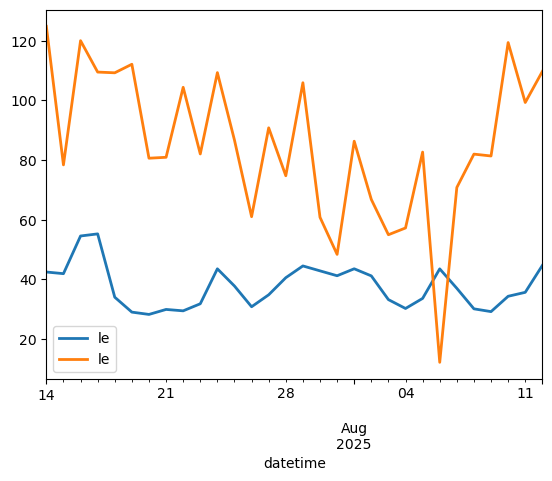

In [74]:
pred_tft_sc = TimeSeries.from_dataframe(pred_tft_scaled.mean(axis=2).to_dataframe().iloc[:,::-1].rename(columns={'nee': 'le', 'le': 'nee'}))
pred_tft = target_scaler.inverse_transform(pred_tft_sc)

pred_tft['nee'].plot()
future_target['nee'].plot()
plt.figure()
pred_tft['le'].plot()
future_target['le'].plot()

Only 1 TimeSeries (lists) were provided which is lower than the number of series (n=6) used to fit Scaler. This can result in a mismatch between the series and the underlying transformers.


<Axes: xlabel='datetime'>

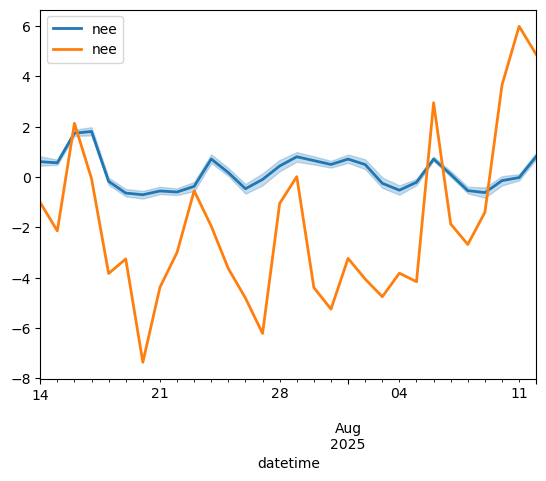

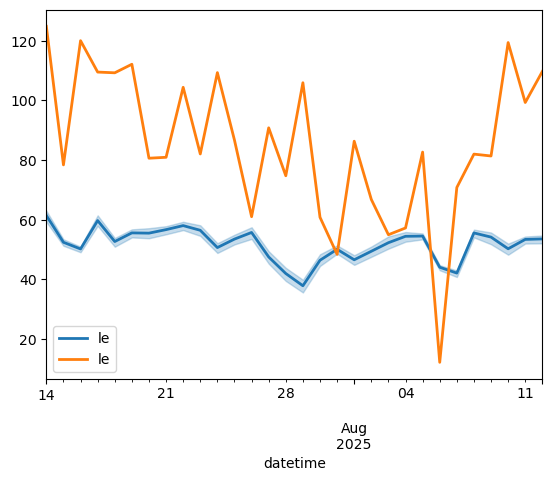

In [75]:
pred_tft = target_scaler.inverse_transform(pred_tft_scaled)

pred_tft['nee'].plot()
future_target['nee'].plot()
plt.figure()
pred_tft['le'].plot()
future_target['le'].plot()